# Macro-State Dependence of the Attention Signal

The research question asks whether the attention signal's predictability depends on interest rates, oil prices, inflation, supply-chain conditions, and the business cycle. `climate_alpha_analysis` only uses these variables to purify the signal. This notebook tests the dependence directly: does attention at month $t$ predict the Brown leg's factor-neutral return at $t+1$ differently depending on the macro state at $t$?

Signal, residual, and purification are rebuilt exactly as in `climate_alpha_analysis`. A negative slope means high attention predicts lower Brown returns, i.e. the sign the Short-Brown strategy needs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
FIGURES = ROOT / "outputs" / "figures"
TABLES = ROOT / "outputs" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

FACTOR_COLS = ["Mkt-RF", "SMB", "HML"]
HOLDOUT_START = "2022-08-31"
END = "2026-07-31"
MIN_MONTHS = 12

## 1. Rebuild the Brown residual and the attention signals

In [2]:
emissions = pd.read_csv(DATA / "emissions_ff_industry.csv")
industries = pd.read_csv(DATA / "ff49_industry_monthly.csv", parse_dates=["date"]).set_index("date")
factors = pd.read_csv(DATA / "ff3_factors_monthly.csv", parse_dates=["date"]).set_index("date")
macro = pd.read_csv(DATA / "macro_monthly.csv", parse_dates=["date"]).set_index("date")

emissions.columns = emissions.columns.str.strip().str.lower()
emissions["ff"] = emissions["ff"].str.strip()
ranked = emissions.sort_values("emissions_intensity")
HIGH5 = ranked.tail(5)["ff"].tolist()
brown_leg = industries[HIGH5].mean(axis=1) - factors["RF"]

def rolling_factor_model(y, x, window=60):
    data = pd.concat([y.rename("y"), x], axis=1).dropna()
    betas = pd.DataFrame(index=data.index, columns=x.columns, dtype=float)
    intercept = pd.Series(index=data.index, dtype=float)
    for end in range(window - 1, len(data)):
        sample = data.iloc[end-window+1:end+1]
        X = np.column_stack([np.ones(window), sample[x.columns].to_numpy()])
        coef, *_ = np.linalg.lstsq(X, sample["y"].to_numpy(), rcond=None)
        intercept.iloc[end], betas.iloc[end] = coef[0], coef[1:]
    hedged = data["y"] - (betas.shift(1) * data[x.columns]).sum(axis=1, min_count=len(x.columns))
    return hedged - intercept.shift(1)

brown_eps = rolling_factor_model(brown_leg, factors[FACTOR_COLS])

def rolling_z(s, window=60, min_periods=36):
    return (s - s.rolling(window, min_periods=min_periods).mean()) / s.rolling(window, min_periods=min_periods).std(ddof=1).replace(0, np.nan)

attention = rolling_z(np.log1p(macro["attention"]))
inflation_yoy = 100*np.log(macro["cpi"]).diff(12)
safe_controls = pd.DataFrame({
    "rate_shock": rolling_z(macro["rate10y"].diff()),
    "oil_return": rolling_z(np.log(macro["wti"]).diff()),
    "inflation_level_l1": rolling_z(inflation_yoy.shift(1)),
    "inflation_accel_l1": rolling_z(inflation_yoy.diff().shift(1)),
    "activity_l1": rolling_z(macro["activity"].shift(1)),
})

def rolling_oos_prediction(y, x, window=120, min_obs=60, ridge=.10):
    panel = x.join(y.rename("target"), how="outer").sort_index()
    pred = pd.Series(np.nan, index=panel.index)
    for date in panel.index:
        if panel.loc[date, x.columns].isna().any(): continue
        train = panel.loc[panel.index < date, [*x.columns, "target"]].dropna().tail(window)
        if len(train) < min_obs: continue
        X = np.column_stack([np.ones(len(train)), train[x.columns].to_numpy(float)])
        penalty = np.eye(X.shape[1])*ridge; penalty[0, 0] = 0
        coef = np.linalg.solve(X.T@X + penalty, X.T@train["target"].to_numpy(float))
        pred.loc[date] = float(np.r_[1, panel.loc[date, x.columns].to_numpy(float)] @ coef)
    return pred

pure_attention = attention - rolling_oos_prediction(attention, safe_controls)
SIGNALS = {"Raw attention": attention, "Purified attention": pure_attention}

forward_eps = brown_eps.shift(-1)
START = pd.concat([pure_attention, forward_eps], axis=1).dropna().index.min()
print("Common sample:", START.date(), "to", END)

Common sample: 1994-01-31 to 2026-07-31


## 2. Real-time macro states

Each state is a 0/1 flag known at the end of month $t$. "High" means above the trailing 10-year median of the series' own past, so the states don't drift with the secular decline in rates. Inflation, activity, and GSCPI are lagged one month for publication delay. The NBER recession flag is left out: it is dated with a 6-18 month lag and covers few months after 1995.

In [3]:
def above_past_median(s, window=120, min_periods=60):
    median = s.shift(1).rolling(window, min_periods=min_periods).median()
    return (s > median).where(median.notna())

activity_3m = macro["activity"].rolling(3).mean().shift(1)
STATES = pd.DataFrame({
    "High rates": above_past_median(macro["rate10y"]),
    "Rising rates (12m)": (macro["rate10y"].diff(12) > 0).where(macro["rate10y"].diff(12).notna()),
    "Oil up (12m)": (np.log(macro["wti"]).diff(12) > 0).where(macro["wti"].diff(12).notna()),
    "High inflation": above_past_median(inflation_yoy.shift(1)),
    "Weak activity (CFNAI<0)": (activity_3m < 0).where(activity_3m.notna()),
    "Supply-chain stress (GSCPI>0)": (macro["supply_chain"].shift(1) > 0).where(macro["supply_chain"].shift(1).notna()),
}).astype(float)

share = pd.DataFrame({
    "Full sample": STATES.loc[START:END].mean(),
    "Pre-holdout": STATES.loc[START:"2022-07-31"].mean(),
    "Holdout Aug2022-Jul2026": STATES.loc[HOLDOUT_START:END].mean(),
})
print("Share of months each state is on:")
display(share)

Share of months each state is on:


,Full sample,Pre-holdout,Holdout Aug2022-Jul2026
High rates,0.192,0.079,1.000
Rising rates (12m),0.450,0.408,0.750
Oil up (12m),0.565,0.592,0.375
High inflation,0.442,0.376,0.917
Weak activity (CFNAI<0),0.514,0.472,0.812
Supply-chain stress (GSCPI>0),0.355,0.346,0.417


**Finding.** The holdout is a macro regime the pre-holdout sample barely saw: rates are above their 10-year median in 47 of 48 holdout months (vs. 27 of ~340 months before), and inflation is high in 92% of them. Any state that matters for the signal is therefore almost fully "on" in the holdout.

## 3. State-dependent predictive slopes

For each signal $A$ and state $S$, with both $A_t$ and the forward residual standardized over the sample (so slopes are on the same scale as an IC):
$$\varepsilon_{t+1} = a + c\,S_t + b_{off}\,A_t(1-S_t) + b_{on}\,A_t S_t + u_{t+1}$$
$b_{on}$ and $b_{off}$ are the signal's slope inside and outside the state; the test of interest is $b_{on}-b_{off}$. Newey-West standard errors, 6 lags. Slopes are left blank when either side of the state has fewer than 12 months.

In [4]:
def newey_west(y, X, lags=6):
    X = np.column_stack([np.ones(len(X)), X])
    inv = np.linalg.pinv(X.T @ X)
    coef = inv @ X.T @ y
    xu = X * (y - X @ coef)[:, None]
    meat = xu.T @ xu
    for lag in range(1, min(lags, len(y) - 1) + 1):
        gamma = xu[lag:].T @ xu[:-lag]
        meat += (1 - lag/(lags + 1)) * (gamma + gamma.T)
    return coef, inv @ meat @ inv

def zscore(s): return (s - s.mean()) / s.std(ddof=1)

def state_slopes(signal, state, start, end):
    data = pd.concat([signal.rename("A"), state.rename("S"), forward_eps.rename("y")], axis=1).loc[start:end].dropna()
    a, y, s = zscore(data["A"]).to_numpy(), zscore(data["y"]).to_numpy(), data["S"].to_numpy()
    n_on, n_off = int(s.sum()), int((1 - s).sum())
    if min(n_on, n_off) < MIN_MONTHS:
        # Too few months on one side of the state to estimate its slope
        return {"n": len(data), "n_on": n_on, "slope_off": np.nan, "t_off": np.nan,
                "slope_on": np.nan, "t_on": np.nan, "diff": np.nan, "t_diff": np.nan}
    coef, cov = newey_west(y, np.column_stack([s, a*(1-s), a*s]))
    b_off, b_on = coef[2], coef[3]
    se_off, se_on = np.sqrt(cov[2, 2]), np.sqrt(cov[3, 3])
    se_diff = np.sqrt(cov[2, 2] + cov[3, 3] - 2*cov[2, 3])
    return {"n": len(data), "n_on": n_on, "slope_off": b_off, "t_off": b_off/se_off,
            "slope_on": b_on, "t_on": b_on/se_on, "diff": b_on - b_off, "t_diff": (b_on - b_off)/se_diff}

rows = []
for sig_name, sig in SIGNALS.items():
    for state_name in STATES:
        rows.append({"signal": sig_name, "state": state_name, **state_slopes(sig, STATES[state_name], START, END)})
full_table = pd.DataFrame(rows)

def holm(pvalues):
    p = np.asarray(pvalues, float); m = len(p); order = np.argsort(p)
    adjusted = np.empty(m); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * p[i]); adjusted[i] = min(running, 1.0)
    return adjusted

from scipy import stats
full_table["p_diff"] = 2*(1 - stats.norm.cdf(full_table["t_diff"].abs()))
full_table["holm_p"] = holm(full_table["p_diff"])
display(full_table.set_index(["signal", "state"]))
full_table.to_csv(TABLES / "macro_state_slopes.csv", index=False)

n  n_on  slope_off  t_off  \
signal             state                                                        
Raw attention      High rates                     390    74     -0.063 -1.008   
                   Rising rates (12m)             390   175     -0.002 -0.035   
                   Oil up (12m)                   390   220      0.119  1.502   
                   High inflation                 390   172      0.062  0.720   
                   Weak activity (CFNAI<0)        390   201     -0.012 -0.153   
                   Supply-chain stress (GSCPI>0)  345   122      0.069  1.090   
Purified attention High rates                     388    72     -0.035 -0.650   
                   Rising rates (12m)             388   175      0.005  0.080   
                   Oil up (12m)                   388   220      0.132  1.872   
                   High inflation                 388   171      0.076  1.137   
                   Weak activity (CFNAI<0)        388   199      0.008  0.126   
                   Supply-chain stress (GSCPI>0)  343   122      0.075  1.202   

                                                  slope_on   t_on   diff  \
signal             state                                                   
Raw attention      High rates                        0.166  1.653  0.229   
                   Rising rates (12m)                0.023  0.320  0.026   
                   Oil up (12m)                     -0.138 -2.009 -0.258   
                   High inflation                   -0.065 -0.916 -0.128   
                   Weak activity (CFNAI<0)          -0.000 -0.007  0.011   
                   Supply-chain stress (GSCPI>0)    -0.171 -2.047 -0.241   
Purified attention High rates                        0.175  1.694  0.210   
                   Rising rates (12m)                0.044  0.686  0.039   
                   Oil up (12m)                     -0.101 -1.734 -0.233   
                   High inflation                   -0.050 -0.769 -0.127   
                   Weak activity (CFNAI<0)           0.015  0.236  0.007   
                   Supply-chain stress (GSCPI>0)    -0.105 -1.462 -0.180   

                                                  t_diff  p_diff  holm_p  
signal             state                                                  
Raw attention      High rates                      1.831   0.067   0.585  
                   Rising rates (12m)              0.257   0.797   1.000  
                   Oil up (12m)                   -2.335   0.020   0.215  
                   High inflation                 -1.083   0.279   1.000  
                   Weak activity (CFNAI<0)         0.116   0.908   1.000  
                   Supply-chain stress (GSCPI>0)  -2.295   0.022   0.217  
Purified attention High rates                      1.710   0.087   0.610  
                   Rising rates (12m)              0.424   0.672   1.000  
                   Oil up (12m)                   -2.423   0.015   0.185  
                   High inflation                 -1.339   0.181   1.000  
                   Weak activity (CFNAI<0)         0.078   0.937   1.000  
                   Supply-chain stress (GSCPI>0)  -1.845   0.065   0.585

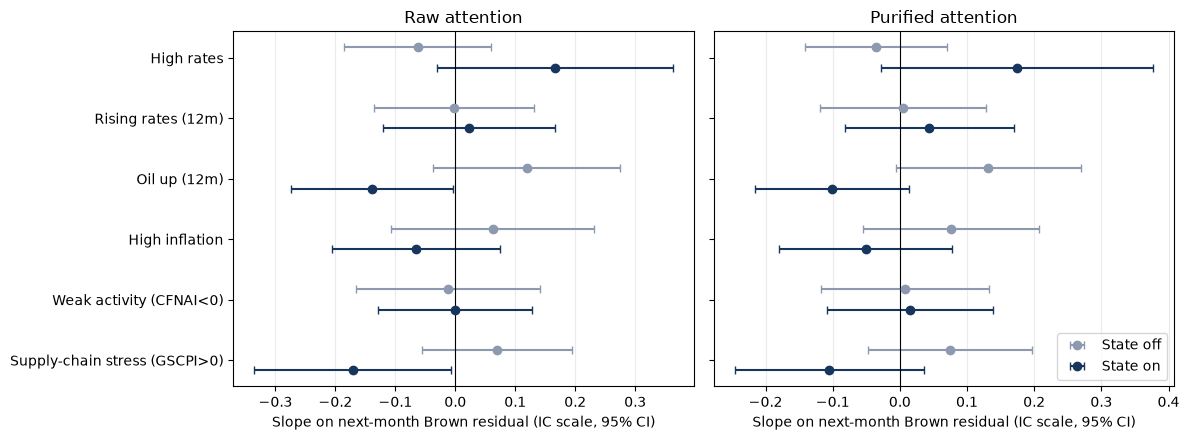

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (sig_name, grp) in zip(axes, full_table.groupby("signal", sort=False)):
    y = np.arange(len(grp))
    for offset, col, t_col, label, color in [(-.17, "slope_off", "t_off", "State off", "#8D99AE"), (.17, "slope_on", "t_on", "State on", "#17365D")]:
        se = (grp[col] / grp[t_col]).abs()
        ax.errorbar(grp[col], y + offset, xerr=1.96*se, fmt="o", color=color, capsize=3, label=label)
    ax.axvline(0, color="black", lw=.8)
    ax.set_yticks(y, grp["state"]); ax.set_title(sig_name); ax.grid(axis="x", alpha=.25)
    ax.set_xlabel("Slope on next-month Brown residual (IC scale, 95% CI)")
axes[0].invert_yaxis(); axes[1].legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES / "figure_4_macro_state_slopes.pdf"); fig.savefig(FIGURES / "figure_4_macro_state_slopes.png", dpi=150)
plt.show()

**Finding.** Three states change the signal's behavior, none of them robustly:

- **Oil up / supply-chain stress:** attention has the right (negative) sign only when oil has risen over the past year (slope about -0.10 to -0.14) or supply chains are stressed (-0.11 to -0.17); otherwise the slope is slightly positive. The differences have individual $p \approx 0.02$ (0.07 for supply chains with purified attention).
- **High rates:** the slope turns the wrong way (about +0.17, $t \approx 1.7$), against roughly zero otherwise.
- **Rising rates, high inflation, weak activity:** no dependence.

After Holm-Bonferroni across the 12 tests, no interaction survives (smallest adjusted $p = 0.19$).

## 4. Does the state explain the holdout failure?

The same regression estimated separately on the pre-holdout sample and the August 2022-July 2026 holdout. If a macro state explains the holdout sign flip, the in-state slope should keep its sign across both samples and the flip should come from the holdout spending more time in the "wrong" state.

In [6]:
rows = []
for sig_name, sig in SIGNALS.items():
    for state_name in STATES:
        for period, (s, e) in {"Pre-holdout": (START, "2022-07-31"), "Holdout": (HOLDOUT_START, END)}.items():
            r = state_slopes(sig, STATES[state_name], s, e)
            rows.append({"signal": sig_name, "state": state_name, "period": period,
                         "n_on": r["n_on"], "slope_off": r["slope_off"], "slope_on": r["slope_on"], "t_diff": r["t_diff"]})
split_table = pd.DataFrame(rows).pivot_table(index=["signal", "state"], columns="period",
                                             values=["n_on", "slope_off", "slope_on"], sort=False)
display(split_table)
split_table.to_csv(TABLES / "macro_state_slopes_by_period.csv")

n_on          \
period                                           Pre-holdout Holdout   
signal             state                                               
Raw attention      High rates                         27.000  47.000   
                   Rising rates (12m)                140.000  35.000   
                   Oil up (12m)                      203.000  17.000   
                   High inflation                    129.000  43.000   
                   Weak activity (CFNAI<0)           162.000  39.000   
                   Supply-chain stress (GSCPI>0)     103.000  19.000   
Purified attention High rates                         27.000  45.000   
                   Rising rates (12m)                140.000  35.000   
                   Oil up (12m)                      203.000  17.000   
                   High inflation                    129.000  42.000   
                   Weak activity (CFNAI<0)           162.000  37.000   
                   Supply-chain stress (GSCPI>0)     103.000  19.000   

                                                   slope_off          \
period                                           Pre-holdout Holdout   
signal             state                                               
Raw attention      High rates                         -0.063     NaN   
                   Rising rates (12m)                  0.003  -0.220   
                   Oil up (12m)                        0.118   0.139   
                   High inflation                      0.056     NaN   
                   Weak activity (CFNAI<0)            -0.023     NaN   
                   Supply-chain stress (GSCPI>0)       0.026   0.262   
Purified attention High rates                         -0.036     NaN   
                   Rising rates (12m)                  0.013     NaN   
                   Oil up (12m)                        0.132   0.130   
                   High inflation                      0.077     NaN   
                   Weak activity (CFNAI<0)            -0.002     NaN   
                   Supply-chain stress (GSCPI>0)       0.036   0.266   

                                                    slope_on          
period                                           Pre-holdout Holdout  
signal             state                                              
Raw attention      High rates                          0.255     NaN  
                   Rising rates (12m)                 -0.059   0.173  
                   Oil up (12m)                       -0.154   0.001  
                   High inflation                     -0.124     NaN  
                   Weak activity (CFNAI<0)            -0.028     NaN  
                   Supply-chain stress (GSCPI>0)      -0.129  -1.133  
Purified attention High rates                          0.242     NaN  
                   Rising rates (12m)                 -0.027     NaN  
                   Oil up (12m)                       -0.117   0.105  
                   High inflation                     -0.110     NaN  
                   Weak activity (CFNAI<0)            -0.010     NaN  
                   Supply-chain stress (GSCPI>0)      -0.069  -0.858

**Finding.** High rates are the one state that could explain the holdout failure. In the 27 high-rate months before the holdout, attention already had the wrong sign (slope about +0.25). The holdout is almost entirely high-rate and shows the same wrong sign (the IC of about +0.12 in `climate_alpha_analysis`). The holdout can't be split by rate state because rates are low in at most a few of its months.

The oil result does not carry over: the right-sign slope in oil-up months (about -0.12 to -0.15) goes to zero or positive in the holdout's 17 oil-up months. Supply-chain stress keeps the right sign in the holdout, but on only 19 months.

Most holdout cells are blank because the holdout spends almost all its time on one side of each state.

## Conclusion

The attention signal's predictability does appear to depend on the macro state, most plausibly on the level of interest rates. It works, weakly, in low-rate and oil-up or supply-stressed environments and reverses when rates are high, which is the environment the holdout sits in. This offers an economic reading of the holdout failure (duration-sensitive Green industries suffer when rates are high, whatever climate attention does) rather than pure noise.

The evidence is suggestive, not conclusive: no interaction survives multiple-testing correction, the high-rate evidence before the holdout rests on 27 months, and these states were chosen after the holdout failure was known. It does not change the "Do not implement" verdict. A rate-conditioned version of the strategy would need new out-of-sample data before it could be trusted.